# Titanic Survival Prediction

## Objective
Build and compare multiple learning classification models to predict passenger survival on the Titanic.

## Models Compared
- Logistic Regression
- K-Nearest Neighbors
- Gaussian Naive Bayes
- Decision Tree
- Support Vector Machine

## Success Metric
- Primary: F1 Score
- Secondary: Accuracy, Precision, Recall

In [1]:
# Data Manipulation
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


<Axes: >

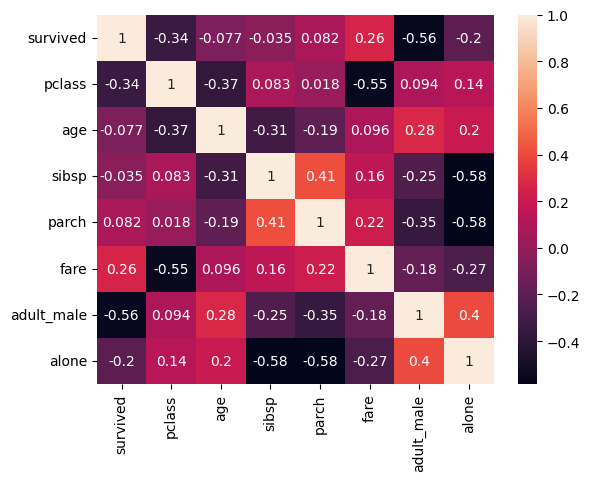

In [6]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

In [7]:
df.groupby("sex")["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

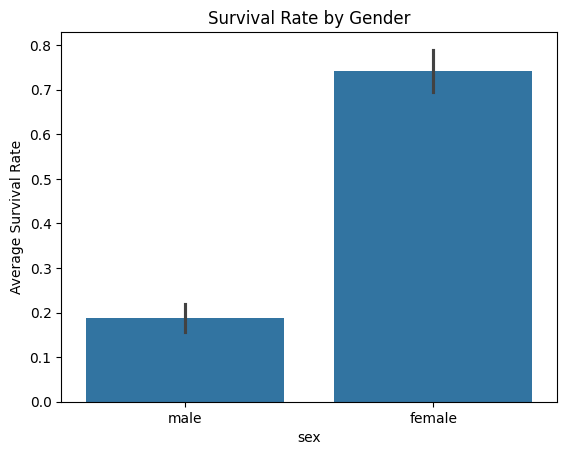

In [8]:
sns.barplot(data=df, x="sex", y="survived")

plt.title("Survival Rate by Gender")
plt.ylabel("Average Survival Rate")
plt.show()

In [9]:
df.groupby("pclass")["survived"].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

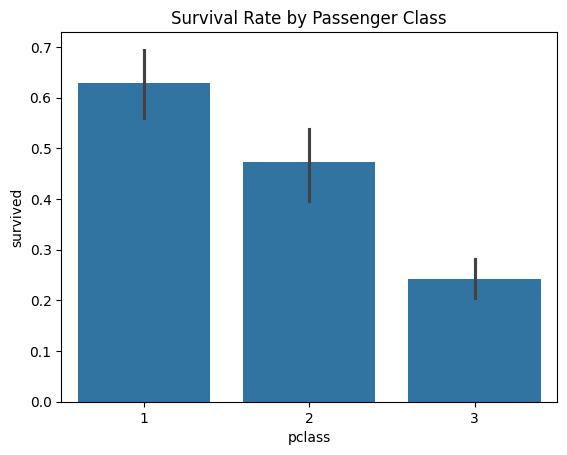

In [10]:
sns.barplot(data=df, x="pclass", y="survived")

plt.title("Survival Rate by Passenger Class")
plt.show()

In [11]:
df[["fare", "survived"]].corr()

,fare,survived
fare,1.000000,0.257307
survived,0.257307,1.000000


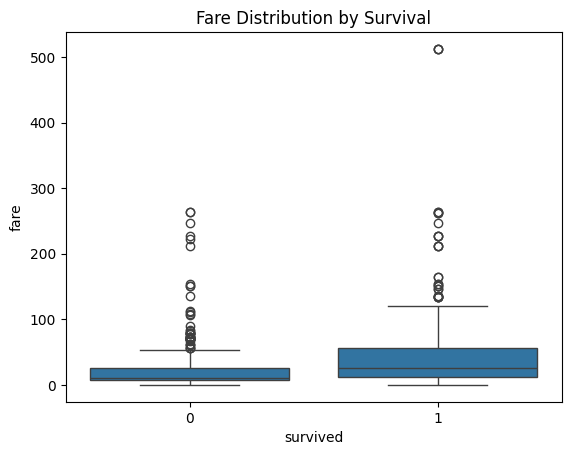

In [12]:
sns.boxplot(data=df, x="survived", y="fare")

plt.title("Fare Distribution by Survival")
plt.show()

### Observations

• Female passengers survived significantly more often.

• First-class passengers had higher survival.

• Fare positively correlates with survival.

• Age, Deck and Embark Town contains missing values.

## Feature Selection Based on Correlation

To reduce noise and retain only the most informative features, we evaluated the correlation of each numerical feature with the target variable. Features with an absolute correlation coefficient less than **0.20** were considered to have a weak linear relationship with the target and were removed from the dataset. This helps simplify the model and can improve interpretability.

In [13]:
df.drop(['deck','embark_town', 'alive', 'class', 'who', 'adult_male'], axis = 1, inplace = True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [15]:
# Replacing missing values of 'age' with mean.
df['age'].fillna(df['age'].mean(), inplace = True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [17]:
# Dropping rows with missing 'embarked' values
df.dropna(subset = ['embarked'], inplace = True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    object 
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     889 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 63.4+ KB


In [19]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

In [20]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22.0,1,0,7.2500,2,False
1,1,1,0,38.0,1,0,71.2833,0,False
2,1,3,0,26.0,0,0,7.9250,2,True
3,1,1,0,35.0,1,0,53.1000,2,False
4,0,3,1,35.0,0,0,8.0500,2,True


In [21]:
# Changing Data Type to Integer.
df = df.astype(int)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,0,3,1,22,1,0,7,2,0
1,1,1,0,38,1,0,71,0,0
2,1,3,0,26,0,0,7,2,1
3,1,1,0,35,1,0,53,2,0
4,0,3,1,35,0,0,8,2,1


In [22]:
# Preparing Features (X) and Target Variable (y)
X = df.drop("survived", axis = 1)
y = df['survived']

In [23]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Feature Scaling

Required for:-
- Logistic Regression
- KNN
- SVM

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled


array([[-1.58410418, -1.40530972, -0.58667407, ...,  2.42752104,
         0.58770431,  0.81076671],
       [ 0.8122747 , -1.40530972, -0.05336323, ..., -0.35872483,
        -1.95246446, -1.23340042],
       [ 0.8122747 ,  0.71158691,  0.17519856, ..., -0.50108776,
         0.58770431,  0.81076671],
       ...,
       [-1.58410418, -1.40530972,  1.39419477, ..., -0.13501166,
         0.58770431,  0.81076671],
       [ 0.8122747 , -1.40530972, -0.66286134, ...,  0.04802639,
         0.58770431, -1.23340042],
       [ 0.8122747 ,  0.71158691,  0.25138582, ..., -0.4807502 ,
         0.58770431,  0.81076671]])

In [25]:
X_test_scaled = scaler.fit_transform(X_test)
X_test_scaled

array([[ 0.87837838,  0.83380939, -0.05614186, ..., -0.48065958,
         0.5836712 ,  0.82416338],
       [-1.52702703, -1.19931487, -1.19358508, ...,  1.70666776,
         0.5836712 , -1.21335165],
       [ 0.87837838, -1.19931487, -1.19358508, ..., -0.40323207,
        -1.88998295, -1.21335165],
       ...,
       [ 0.87837838, -1.19931487,  0.75631758, ..., -0.01609448,
         0.5836712 , -1.21335165],
       [ 0.87837838, -1.19931487,  0.35008786, ..., -0.32580455,
         0.5836712 , -1.21335165],
       [ 0.87837838, -1.19931487, -2.00604452, ..., -0.30644767,
         0.5836712 , -1.21335165]])

# Logistic Regression

In [26]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [27]:
y_pred = model.predict(X_test)
y_pred

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [28]:
y_test

281    0
435    1
39     1
418    0
585    1
      ..
433    0
807    0
25     1
85     1
10     1
Name: survived, Length: 178, dtype: int64

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
accuracy_score(y_test, y_pred)

0.8033707865168539

In [30]:
confusion_matrix(y_test, y_pred)

array([[90, 19],
       [16, 53]])

In [31]:
results = []
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
})

In [32]:
from tabulate import tabulate
report = classification_report(y_test, y_pred, output_dict = True)
report_df = pd.DataFrame(report).transpose()



print(tabulate(report_df,
               headers='keys',
               tablefmt='fancy_grid',
               floatfmt=".3f"))

╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │       0.849 │    0.826 │      0.837 │   109.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │       0.736 │    0.768 │      0.752 │    69.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │       0.803 │    0.803 │      0.803 │     0.803 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │       0.793 │    0.797 │      0.794 │   178.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │       0.805 │    0.803 │      0.804 │   178.000 │
╘══════════════╧═════════════╧══════════╧════════════╧═══════════╛


# KNN

In [33]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [34]:
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_knn

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [35]:
y_test

281    0
435    1
39     1
418    0
585    1
      ..
433    0
807    0
25     1
85     1
10     1
Name: survived, Length: 178, dtype: int64

In [36]:
accuracy_score(y_test, y_pred_knn)

0.7752808988764045

In [37]:
confusion_matrix(y_test, y_pred_knn)

array([[89, 20],
       [20, 49]])

In [38]:
results.append({
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1 Score": f1_score(y_test, y_pred_knn)
})

In [39]:
report = classification_report(y_test, y_pred_knn, output_dict = True)
report_df = pd.DataFrame(report).transpose()



print(tabulate(report_df,
               headers='keys',
               tablefmt='fancy_grid',
               floatfmt=".3f"))

╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │       0.817 │    0.817 │      0.817 │   109.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │       0.710 │    0.710 │      0.710 │    69.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │       0.775 │    0.775 │      0.775 │     0.775 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │       0.763 │    0.763 │      0.763 │   178.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │       0.775 │    0.775 │      0.775 │   178.000 │
╘══════════════╧═════════════╧══════════╧════════════╧═══════════╛


# Naive Bayes

In [40]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()
model_NB.fit(X_train,y_train)


GaussianNB()

In [41]:
y_pred_NB = model_NB.predict(X_test)
y_pred_NB

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [42]:
y_test

281    0
435    1
39     1
418    0
585    1
      ..
433    0
807    0
25     1
85     1
10     1
Name: survived, Length: 178, dtype: int64

In [43]:
accuracy_score(y_test, y_pred_NB)

0.7752808988764045

In [44]:
confusion_matrix(y_test, y_pred_NB)

array([[84, 25],
       [15, 54]])

In [45]:
results.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred_NB),
    "Precision": precision_score(y_test, y_pred_NB),
    "Recall": recall_score(y_test, y_pred_NB),
    "F1 Score": f1_score(y_test, y_pred_NB)
})

In [46]:
report = classification_report(y_test, y_pred_NB, output_dict = True)
report_df = pd.DataFrame(report).transpose()



print(tabulate(report_df,
               headers='keys',
               tablefmt='fancy_grid',
               floatfmt=".3f"))

╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │       0.848 │    0.771 │      0.808 │   109.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │       0.684 │    0.783 │      0.730 │    69.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │       0.775 │    0.775 │      0.775 │     0.775 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │       0.766 │    0.777 │      0.769 │   178.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │       0.785 │    0.775 │      0.777 │   178.000 │
╘══════════════╧═════════════╧══════════╧════════════╧═══════════╛


# Decision Tree

In [47]:
from sklearn.tree import DecisionTreeClassifier
model_DT = DecisionTreeClassifier()
model_DT.fit(X_train_scaled, y_train)

DecisionTreeClassifier()

In [48]:
y_pred_DT = model_DT.predict(X_test_scaled)
y_pred_DT

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0])

In [49]:
y_test

281    0
435    1
39     1
418    0
585    1
      ..
433    0
807    0
25     1
85     1
10     1
Name: survived, Length: 178, dtype: int64

In [50]:
accuracy_score(y_test, y_pred_DT)

0.7752808988764045

In [51]:
confusion_matrix(y_test,y_pred_DT)

array([[88, 21],
       [19, 50]])

In [52]:
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_DT),
    "Precision": precision_score(y_test, y_pred_DT),
    "Recall": recall_score(y_test, y_pred_DT),
    "F1 Score": f1_score(y_test, y_pred_DT)
})

In [53]:
report = classification_report(y_test, y_pred_DT, output_dict = True)
report_df = pd.DataFrame(report).transpose()



print(tabulate(report_df,
               headers='keys',
               tablefmt='fancy_grid',
               floatfmt=".3f"))

╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │       0.822 │    0.807 │      0.815 │   109.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │       0.704 │    0.725 │      0.714 │    69.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │       0.775 │    0.775 │      0.775 │     0.775 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │       0.763 │    0.766 │      0.765 │   178.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │       0.777 │    0.775 │      0.776 │   178.000 │
╘══════════════╧═════════════╧══════════╧════════════╧═══════════╛


# SVM

In [54]:
from sklearn.svm import SVC
model_svm = SVC(kernel = 'rbf')
model_svm.fit(X_train_scaled, y_train)

SVC()

In [55]:
y_pred_svc = model_svm.predict(X_test_scaled)
y_pred_svc

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [56]:
y_test

281    0
435    1
39     1
418    0
585    1
      ..
433    0
807    0
25     1
85     1
10     1
Name: survived, Length: 178, dtype: int64

In [57]:
accuracy_score(y_test,y_pred_svc)

0.8258426966292135

In [58]:
confusion_matrix(y_test,y_pred_svc)

array([[96, 13],
       [18, 51]])

In [59]:
results.append({
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svc),
    "Precision": precision_score(y_test, y_pred_svc),
    "Recall": recall_score(y_test, y_pred_svc),
    "F1 Score": f1_score(y_test, y_pred_svc)
})

In [60]:
report = classification_report(y_test, y_pred_svc, output_dict = True)
report_df = pd.DataFrame(report).transpose()



print(tabulate(report_df,
               headers='keys',
               tablefmt='fancy_grid',
               floatfmt=".3f"))

╒══════════════╤═════════════╤══════════╤════════════╤═══════════╕
│              │   precision │   recall │   f1-score │   support │
╞══════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ 0            │       0.842 │    0.881 │      0.861 │   109.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ 1            │       0.797 │    0.739 │      0.767 │    69.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ accuracy     │       0.826 │    0.826 │      0.826 │     0.826 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ macro avg    │       0.819 │    0.810 │      0.814 │   178.000 │
├──────────────┼─────────────┼──────────┼────────────┼───────────┤
│ weighted avg │       0.825 │    0.826 │      0.825 │   178.000 │
╘══════════════╧═════════════╧══════════╧════════════╧═══════════╛


In [61]:
comparison_df = pd.DataFrame(results)

# Model Comparison Table

In [62]:
comparison_df.style\
    .background_gradient(cmap="Blues")\
    .highlight_max(color="#90EE90")\
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt"
    })\
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#40466e"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold")
            ]
        }
    ])\



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803371,0.736111,0.768116,0.751773
1,KNN,0.775281,0.710145,0.710145,0.710145
2,Naive Bayes,0.775281,0.683544,0.782609,0.729730
3,Decision Tree,0.775281,0.704225,0.724638,0.714286
4,SVM,0.825843,0.796875,0.739130,0.766917


## Best Performing Model

Support Vector Machine

Accuracy : 82.5%

F1 Score : 76.6%

Reasons

• Highest overall performance

• Good balance between Precision and Recall

• Lowest False Positive rate

## Limitations

• Dataset is relatively small.

• Missing values required imputation.

• Limited feature engineering.

• Hyperparameter tuning was minimal.

# Future Improvements

Hyperparameter Tuning

Cross Validation

Ensemble Models

Random Forest

XGBoost

LightGBM

Stacking

# Conclusion

• Performed data cleaning and preprocessing.

• Conducted exploratory data analysis.

• Trained five classification models.

• Compared models using multiple evaluation metrics.

• SVM achieved the best overall performance.

• Feature scaling significantly improved KNN and SVM.

• Model comparison demonstrated the importance of selecting appropriate algorithms for structured tabular data.